# Risk indicators — Global Forest Watch (live, needs a key)

The third risk source is the **Global Forest Watch (GFW) Data API**. It
serves forest indicators — here **annual tree-cover loss** by country —
and the GADM admin geometry those indicators are computed over.

Unlike ThinkHazard! and INFORM, GFW needs a **free API key**:

1. Create one by following the GFW guide:
   <https://www.globalforestwatch.org/help/developers/guides/create-and-use-an-api-key/>.
2. Make it available to the notebook via the **`GFW_API_KEY` environment
   variable** (e.g. `export GFW_API_KEY=...` before launching Jupyter, or
   set it in your shell profile).

The backend reads `GFW_API_KEY` from the environment automatically — the
key is **never** passed in code or printed in this notebook. If the key is
missing, constructing a `gfw:*` request raises an `AuthenticationError`
naming `GFW_API_KEY`.

In [1]:
import tempfile

import matplotlib.pyplot as plt
from earthlens.earthlens import EarthLens

OUT = tempfile.mkdtemp()  # the tabular download also writes a CSV here

## Annual tree-cover loss by country

`variables=["gfw:tree_cover_loss"]` runs GFW's SQL query for the chosen
country (canopy density ≥ 30%) and returns one row per year. The
`data_source="gfw"` alias reaches the same risk-indicators backend.

In [2]:
loss = EarthLens(
    data_source="gfw",
    variables=["gfw:tree_cover_loss"],
    country="KEN",
    path=OUT,
).download()

print(loss.shape)
loss.head()

2026-06-27 04:27:57 | INFO | pyramids.base.config | Logging is configured.


2026-06-27 04:27:59.448 | WARNING  | earthlens.risk_indicators._helpers:_request_json:133 - risk-indicators: transient fetch error from https://data-api.globalforestwatch.org/dataset/gadm__tcl__iso_change/v20260424/query/json (('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None))); retry 1/2.


2026-06-27 04:28:00.533 | INFO     | earthlens.risk_indicators.backend:_log_citation:419 - RiskIndicators source citation: Global Forest Watch / Hansen-UMD tree cover loss; GADM boundaries — https://www.globalforestwatch.org (CC BY 4.0).


2026-06-27 04:28:00.540 | INFO     | earthlens.risk_indicators.backend:download:377 - RiskIndicators gfw:tree_cover_loss: 25 row(s) written to C:\Users\main\AppData\Local\Temp\tmpcud_1pgw\risk_gfw_tree_cover_loss.csv.


(25, 3)


,iso,umd_tree_cover_loss__year,umd_tree_cover_loss__ha
0,KEN,2001,19027.364861
1,KEN,2002,20286.987739
2,KEN,2003,13553.195406
3,KEN,2004,16988.097531
4,KEN,2005,12745.355935


`umd_tree_cover_loss__year` is the year and `umd_tree_cover_loss__ha` the
hectares of tree-cover loss in that year (UMD/Hansen). Plain pandas from
here — plot the annual series:

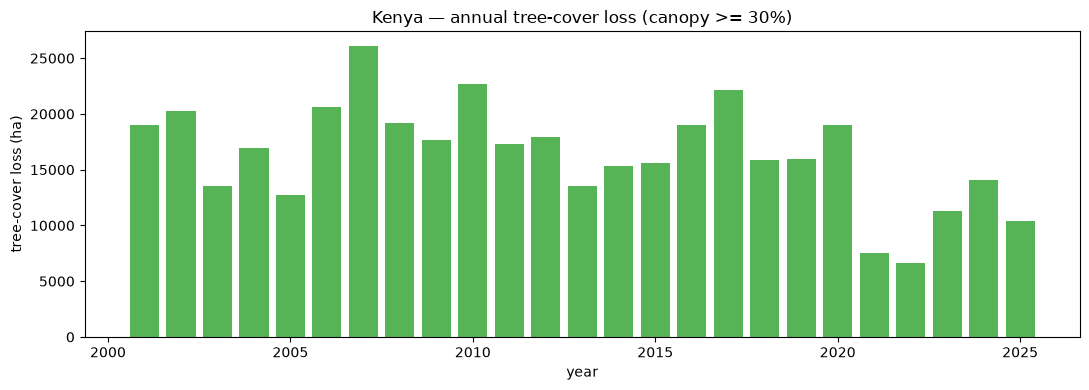

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(
    loss["umd_tree_cover_loss__year"],
    loss["umd_tree_cover_loss__ha"],
    color="tab:green",
    alpha=0.8,
)
ax.set_title("Kenya — annual tree-cover loss (canopy >= 30%)")
ax.set_xlabel("year")
ax.set_ylabel("tree-cover loss (ha)")
fig.tight_layout()

## The admin boundary as a FeatureCollection

`gfw:admin_boundary` is a **vector** dataset: it returns the GADM country
geometry the indicators are computed over as a pyramids
`FeatureCollection` (a `GeoDataFrame` subclass), not a table.

In [4]:
boundary = EarthLens(
    data_source="gfw",
    variables=["gfw:admin_boundary"],
    country="KEN",
    path=OUT,
).download()

print("type:", type(boundary).__name__)
print("features:", len(boundary))
print("crs:", boundary.crs)
print("bounds:", boundary.total_bounds)

2026-06-27 04:28:04.235 | INFO     | earthlens.risk_indicators.backend:_log_citation:419 - RiskIndicators source citation: Global Forest Watch / Hansen-UMD tree cover loss; GADM boundaries — https://www.globalforestwatch.org (CC BY 4.0).


2026-06-27 04:28:04.236 | INFO     | earthlens.risk_indicators.backend:download:370 - RiskIndicators gfw:admin_boundary: returned a FeatureCollection (1 feature(s)).


type: FeatureCollection
features: 1
crs: EPSG:4326
bounds: [33.91014862 -4.67578125 41.92621613  5.05815601]


It carries a CRS (EPSG:4326) and a geometry column, so it plots directly:

Text(139.53703866415054, 0.5, 'latitude')

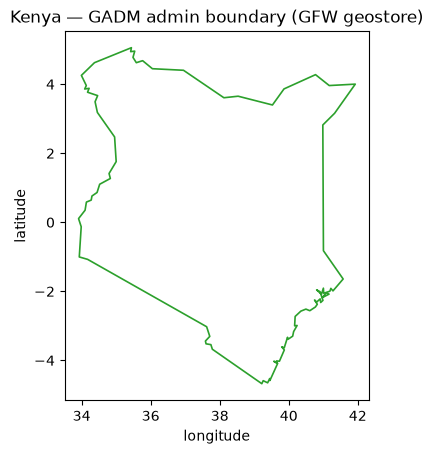

In [5]:
ax = boundary.plot(facecolor="none", edgecolor="tab:green", linewidth=1.2)
ax.set_title("Kenya — GADM admin boundary (GFW geostore)")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")

## Takeaway

- GFW needs a **free key** in `GFW_API_KEY`; the backend reads it from the
  environment — never hard-code or print it.
- `gfw:tree_cover_loss` is **tabular** (a per-year `DataFrame`);
  `gfw:admin_boundary` is **vector** (a `FeatureCollection` that plots
  directly) — the per-instance `OUTPUT_KIND` in action.
- The same `EarthLens(...).download()` call shape serves all three risk
  sources; see the [quickstart](01_risk_indicators_quickstart.ipynb) for
  the public ThinkHazard! / INFORM sources and
  [catalog & behaviour](02_catalog_and_behavior.ipynb) for the full
  dataset list.